# Toronto's subway delays nearly doubled. What's behind them?

The TTC logs every incident on the subway: when, where, which code, and how many minutes it delayed service.
This notebook works through 267,571 incidents from January 2014 to August 2026.

**Short answer:**
1. **Delays nearly doubled.** The subway lost an average of **71,000 minutes a year** to delays in 2023–25,
   up **85%** from 38,000 in 2014–16. Delays of 30 minutes or more went from about 92 a year to 223.
2. **Three-quarters of the increase involves passengers and the public:** disorderly behaviour, people on the
   tracks, passenger alarms and medical emergencies. Disorderly behaviour alone went from 4,800 to 17,100 minutes a
   year and is now the biggest single cause. **Train breakdowns fell 12%.**
3. **Line 1's new signal system worked.** After automatic train control (ATC) went live, Line 1 had about
   **half the signal-failure delays** that Line 2's trend predicts (rate ratio 0.53, 95% CI 0.39–0.73).
4. **One-person train operation added a new kind of delay:** problems with the door-monitoring cameras cost
   Line 1 about 3,600 minutes a year since 2022.

Data: City of Toronto Open Data, TTC Subway Delay Data. Run `python src/fetch_data.py`,
`python src/prepare_data.py` and `python src/run_sql.py` first. All modelling is in SQL (DuckDB): see `sql/`.

In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import StrMethodFormatter

warnings.filterwarnings("ignore")

# the notebook is in the notebooks/ folder, so the project folder is one level up
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

# my chart colours and helpers (titles, footnote, save) are in src/style.py
sys.path.append(str(ROOT / "src"))
from style import BLUE, BLUE_LIGHT, GRID, INK, INK_2, LINE_COLOURS, NEUTRAL, ORANGE, SURFACE, VIOLET
from style import footnote, save, titles

# src/run_sql.py builds all the tables in this DuckDB database
con = duckdb.connect(str(ROOT / "data" / "ttc.duckdb"), read_only=True)


def run_sql(query):
    """Run a SQL query on the database and return the result as a pandas DataFrame."""
    return con.execute(query).df()


pd.set_option("display.precision", 1)
pd.set_option("display.width", 200)

## 1. Data quality

The raw data is 23 Excel sheets and one CSV, typed by hand over 12 years. The line field alone has
**111 different spellings** ("YU/BD", "B/D", "YUS / BD", "BLOOR DANFORTH LINE 2", and bus routes typed into the
subway log), and the location field has **2,221** ("ST GEORGE YUS STATION", "SCARBOROUGH CTR STATIO", typos like
"GLENCARIN STATION"). `src/prepare_data.py` maps them to 5 line values and 75 stations, and records every mapping
in `data/processed/station_mapping.csv`. The pipeline won't publish if any of the checks below fails.

In [2]:
# every data-quality check and whether it passed
run_sql("SELECT check_name, detail, passed FROM dq_results ORDER BY check_name")

,check_name,detail,passed
0,Line 3 rows after closure delay nothing,"17 rows, 0 delay minutes",True
1,cause mart reconciles,631530 vs 631530,True
2,dates in range,2014-01-01 to 2026-08-31,True
3,delay codes documented for 99%+ of rows,1634 rows use codes missing from both publishe...,True
4,every row has a cause group,0 missing,True
5,gap >= delay for 95%+ of delays,96.8% of delays,True
6,line known for 99.5%+ of rows,0.15% unknown,True
7,line rows add up to all-lines rows,631530 vs 631530,True
8,line values cleaned,"1, 2, 3, 4, multiple, unknown",True
9,location matched for 99.5%+ of rows,0.11% unmatched,True


In [3]:
# what the cleaning step changed, step by step
run_sql("SELECT * FROM cleaning_log")

,step,rows
0,raw rows,267842
1,exact duplicates removed,271
2,line filled from station,550
3,clean rows,267571
4,locations mapped to a station,251754
5,locations unknown,292
6,codes not in published lists,1634
7,raw location strings,2221
8,raw line spellings,111


In [4]:
# how the free-text locations were matched to stations (rows = incidents)
run_sql("""
    SELECT location_type,
           method,
           COUNT(*) AS spellings,
           SUM(rows) AS incidents,
           ROUND(100 * SUM(rows) / SUM(SUM(rows)) OVER (), 2) AS pct_of_incidents
    FROM station_mapping
    GROUP BY location_type, method
    ORDER BY incidents DESC
""")

,location_type,method,spellings,incidents,pct_of_incidents
0,station,alias,1237,250786.0,9.4e+01
1,line-wide,rule,205,11921.0,4.5e+00
2,yard or facility,rule,126,3604.0,1.4e+00
3,between stations,alias,404,921.0,3.4e-01
4,unknown,unmatched,209,292.0,1.1e-01
5,station,fuzzy,40,47.0,2.0e-02


In [5]:
# a sample of the messiest spellings and where they went
run_sql("""
    SELECT location_raw, station, location_type, method, rows
    FROM station_mapping
    WHERE location_raw IN ('YONGE BD STATION', 'ST GEORGE YUS STATION', 'SCARB CTR STATION', 'GLENCARIN STATION',
                           'YUS/BD/SHEPPARD SUBWAY', 'UNION STATION TO KING', 'WILSON HOSTLER', 'TMU STATION',
                           'EGLINTON WEST STATION', 'VMC STATION PLATFORM 2')
    ORDER BY rows DESC
""")

,location_raw,station,location_type,method,rows
0,YONGE BD STATION,Bloor-Yonge,station,alias,4925
1,ST GEORGE YUS STATION,St George,station,alias,4255
2,EGLINTON WEST STATION,Cedarvale (Eglinton West),station,alias,2590
3,YUS/BD/SHEPPARD SUBWAY,NaN,line-wide,rule,1069
4,SCARB CTR STATION,Scarborough Centre,station,alias,535
5,TMU STATION,TMU (Dundas),station,alias,425
6,WILSON HOSTLER,Wilson,yard or facility,rule,251
7,UNION STATION TO KING,Union,between stations,alias,91
8,VMC STATION PLATFORM 2,Vaughan Metropolitan Centre,station,alias,22
9,GLENCARIN STATION,Glencairn,station,fuzzy,4


**A note on the measure.** "Delay minutes" is the TTC's own `Min Delay` field: minutes of delay to subway
service caused by an incident. 64% of logged incidents delay nothing (a passenger alarm with no trouble found, an
incident at a yard), so most of the analysis adds up minutes rather than counting rows.

## 2. Delays nearly doubled

In [6]:
yearly = run_sql("SELECT * FROM mart_yearly WHERE line_name = 'All lines' ORDER BY year")
yearly

,year,line_name,incidents_logged,delays,delay_minutes,disruptions_30min,avg_minutes_per_delay
0,2014,All lines,20413,6278,41169.0,97,6.6
1,2015,All lines,21467,5058,35496.0,84,7.0
2,2016,All lines,21157,5698,38275.0,94,6.7
3,2017,All lines,18879,5451,36576.0,104,6.7
4,2018,All lines,20724,7165,48267.0,125,6.7
5,2019,All lines,19143,6753,45493.0,120,6.7
6,2020,All lines,14758,6868,46513.0,136,6.8
7,2021,All lines,16348,7372,53480.0,154,7.2
8,2022,All lines,19880,8972,73094.0,242,8.2
9,2023,All lines,22943,8235,68146.0,228,8.3


In [7]:
# compare an average year at the start (2014-16) with an average year now (2023-25)
base = yearly[(yearly["year"] >= 2014) & (yearly["year"] <= 2016)]
recent = yearly[(yearly["year"] >= 2023) & (yearly["year"] <= 2025)]

columns = ["delay_minutes", "delays", "disruptions_30min"]
summary = pd.DataFrame()
summary["2014-16 (avg year)"] = base[columns].mean()
summary["2023-25 (avg year)"] = recent[columns].mean()

# average length of one delay = total delay minutes / number of delays
summary.loc["minutes per delay"] = [
    base["delay_minutes"].sum() / base["delays"].sum(),
    recent["delay_minutes"].sum() / recent["delays"].sum(),
]

summary["change %"] = (summary["2023-25 (avg year)"] / summary["2014-16 (avg year)"] - 1) * 100
summary.round(1)

,2014-16 (avg year),2023-25 (avg year),change %
delay_minutes,38313.3,71055.7,85.5
delays,5678.0,8906.3,56.9
disruptions_30min,91.7,222.7,142.9
minutes per delay,6.7,8.0,18.2


Both things got worse: there are **more delays** (+57%) and each lasts **longer** (6.7 → 8.0 minutes on average).

Is this just a bigger network? Line 1 grew by six stations in December 2017 and Line 3 closed in July 2023.
Line 2 has had the same 31 stations the whole time, and its delay minutes still rose 65%:

In [8]:
by_line = run_sql("""
    SELECT line_name,
           ROUND(AVG(delay_minutes) FILTER (WHERE year BETWEEN 2014 AND 2016)) AS minutes_2014_16,
           ROUND(AVG(delay_minutes) FILTER (WHERE year BETWEEN 2023 AND 2025)) AS minutes_2023_25
    FROM mart_yearly
    WHERE line_name IN ('Line 1', 'Line 2', 'Line 4', 'All lines')
    GROUP BY line_name
    ORDER BY line_name
""")
by_line["change_pct"] = (by_line["minutes_2023_25"] / by_line["minutes_2014_16"] - 1) * 100
by_line

,line_name,minutes_2014_16,minutes_2023_25,change_pct
0,All lines,38313.0,71056.0,85.5
1,Line 1,15669.0,39529.0,152.3
2,Line 2,16346.0,27033.0,65.4
3,Line 4,1926.0,2880.0,49.5


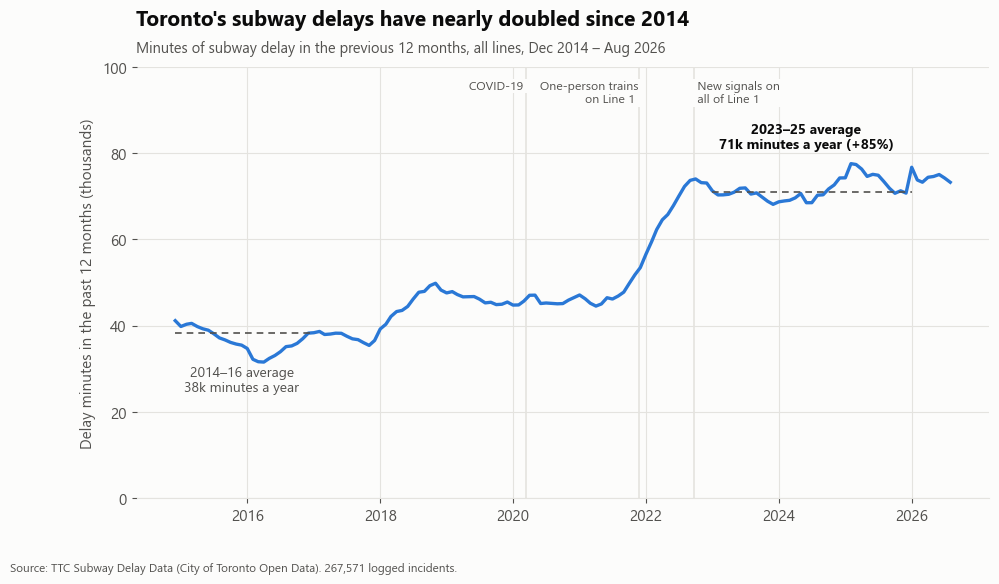

In [9]:
# Chart 1: delay minutes over the previous 12 months, so seasons don't make the line jump around
monthly = run_sql("SELECT * FROM mart_monthly WHERE months_in_window = 12 ORDER BY month")

# the two averages (in thousands of minutes), for the dashed lines
avg_base = base["delay_minutes"].mean() / 1000
avg_recent = recent["delay_minutes"].mean() / 1000
increase_pct = (avg_recent / avg_base - 1) * 100

fig, ax = plt.subplots(figsize=(11, 5.6))
ax.plot(monthly["month"], monthly["minutes_rolling_12m"] / 1000, color=BLUE, lw=2.4)

ax.hlines(avg_base, pd.Timestamp("2014-12-01"), pd.Timestamp("2016-12-31"), color=INK_2, lw=1.2, ls=(0, (4, 3)))
ax.hlines(avg_recent, pd.Timestamp("2023-01-01"), pd.Timestamp("2025-12-31"), color=INK_2, lw=1.2, ls=(0, (4, 3)))
ax.annotate(f"2014–16 average\n{avg_base:.0f}k minutes a year", (pd.Timestamp("2015-12-01"), avg_base),
            xytext=(0, -42), textcoords="offset points", ha="center", color=INK_2, fontsize=10)
ax.text(pd.Timestamp("2024-06-01"), 80.5, f"2023–25 average\n{avg_recent:.0f}k minutes a year (+{increase_pct:.0f}%)",
        ha="center", va="bottom", color=INK, fontsize=10, fontweight="bold")

# grey lines for the events that matter: (date, label, which side of the line the label goes)
events = [
    ("2020-03-15", "COVID-19 ", "right"),
    ("2021-11-21", "One-person trains\non Line 1 ", "right"),
    ("2022-09-24", " New signals on\n all of Line 1", "left"),
]
for date, label, side in events:
    ax.axvline(pd.Timestamp(date), color=GRID, lw=1.2, zorder=0)
    ax.text(pd.Timestamp(date), 97, label, fontsize=8.8, color=INK_2, ha=side, va="top",
            bbox=dict(fc=SURFACE, ec="none", pad=1))

ax.set_ylim(0, 100)
ax.set_ylabel("Delay minutes in the past 12 months (thousands)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
titles(ax, "Toronto's subway delays have nearly doubled since 2014",
       "Minutes of subway delay in the previous 12 months, all lines, Dec 2014 – Aug 2026")
footnote(fig, "Source: TTC Subway Delay Data (City of Toronto Open Data). 267,571 logged incidents.", y=-0.02)
save(fig, "01_delays_trend.png")
plt.show()

## 3. What changed: the causes

Each incident has a TTC delay code (234 codes in use). I grouped them into 13 plain-English causes
(`src/prepare_data.py`, `CAUSE`). 1,634 incidents (0.6%) use codes that appear in neither of the TTC's published
code lists. Most are new in 2026; they were grouped by the code's first letter, which names the responsible
department (S = security, T = transportation, E = equipment).

In [10]:
change = run_sql("SELECT * FROM mart_cause_change ORDER BY change DESC")
change

,cause_group,cause_family,minutes_2014_16,minutes_2023_25,change,change_pct,share_of_net_increase_pct,share_of_recent_minutes_pct
0,Disorderly behaviour & crime,Passengers & public,4805.0,17112.0,12307.0,256.2,37.6,24.1
1,"Alarms, doors & clean-ups",Passengers & public,2693.0,7728.0,5035.0,187.0,15.4,10.9
2,People on the tracks,Passengers & public,2862.0,7591.0,4729.0,165.2,14.4,10.7
3,Door cameras (one-person trains),"Trains, track & signals",164.0,4045.0,3881.0,2371.3,11.9,5.7
4,Medical emergencies,Passengers & public,5170.0,8140.0,2970.0,57.4,9.1,11.5
5,Planned work & closures,"Fire, weather & works",368.0,2558.0,2189.0,594.4,6.7,3.6
6,"Track, power & stations","Trains, track & signals",1912.0,3465.0,1553.0,81.2,4.7,4.9
7,Crew & operations,Crew & operations,4623.0,5978.0,1355.0,29.3,4.1,8.4
8,Signals & communications,"Trains, track & signals",2303.0,3551.0,1248.0,54.2,3.8,5.0
9,Other & unclassified,Other & unclassified,1855.0,1723.0,-132.0,-7.1,-0.4,2.4


In [11]:
# add the causes up into families: passengers & public, trains & track, and so on
families = change.groupby("cause_family")[["minutes_2014_16", "minutes_2023_25", "change"]].sum()
families["share_of_net_increase_pct"] = families["change"] / families["change"].sum() * 100
families.sort_values("change", ascending=False).round(1)

,minutes_2014_16,minutes_2023_25,change,share_of_net_increase_pct
cause_family,,,,
Passengers & public,15530.0,40571.0,25041.0,76.5
"Trains, track & signals",10941.0,16824.0,5883.0,18.0
Crew & operations,4623.0,5978.0,1355.0,4.1
"Fire, weather & works",5364.0,5961.0,596.0,1.8
Other & unclassified,1855.0,1723.0,-132.0,-0.4


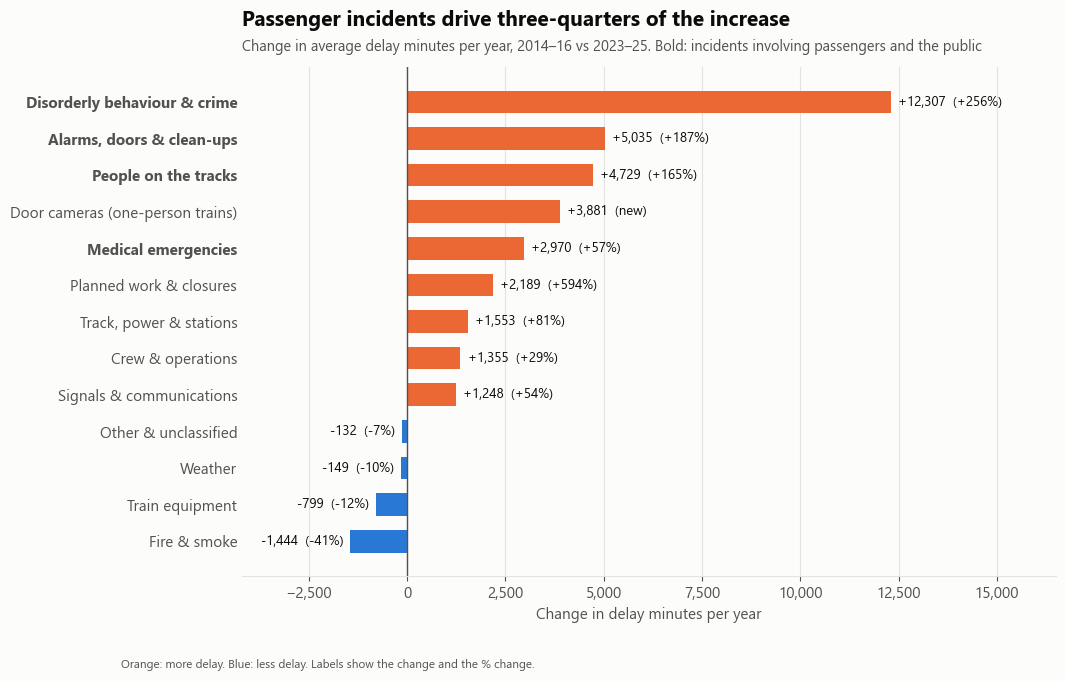

In [12]:
# Chart 2: how much each cause changed (orange = more delay, blue = less)
c = change.sort_values("change")

colours = []
for value in c["change"]:
    if value > 0:
        colours.append(ORANGE)
    else:
        colours.append(BLUE)

fig, ax = plt.subplots(figsize=(10.5, 6.6))
ax.barh(c["cause_group"], c["change"], color=colours, height=0.62)

# label each bar with the change, and the % change (or "new" if the cause barely existed in 2014-16)
for i in range(len(c)):
    value = c["change"].iloc[i]
    pct = c["change_pct"].iloc[i]
    if abs(pct) < 1000:
        label = f"{value:+,.0f}  ({pct:+.0f}%)"
    else:
        label = f"{value:+,.0f}  (new)"
    if value > 0:
        ax.text(value + 180, i, label, va="center", ha="left", fontsize=9.5, color=INK)
    else:
        ax.text(value - 180, i, label, va="center", ha="right", fontsize=9.5, color=INK)

ax.axvline(0, color=INK_2, lw=1)
ax.set_xlim(-4200, 16500)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Change in delay minutes per year")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# make the passenger and public causes bold
passenger_causes = ["Disorderly behaviour & crime", "Alarms, doors & clean-ups", "People on the tracks",
                    "Medical emergencies"]
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() in passenger_causes:
        tick_label.set_fontweight("bold")

titles(ax, "Passenger incidents drive three-quarters of the increase",
       "Change in average delay minutes per year, 2014–16 vs 2023–25. Bold: incidents involving passengers and the public")
footnote(fig, "Orange: more delay. Blue: less delay. Labels show the change and the % change.", y=-0.03)
save(fig, "02_what_changed.png")
plt.show()

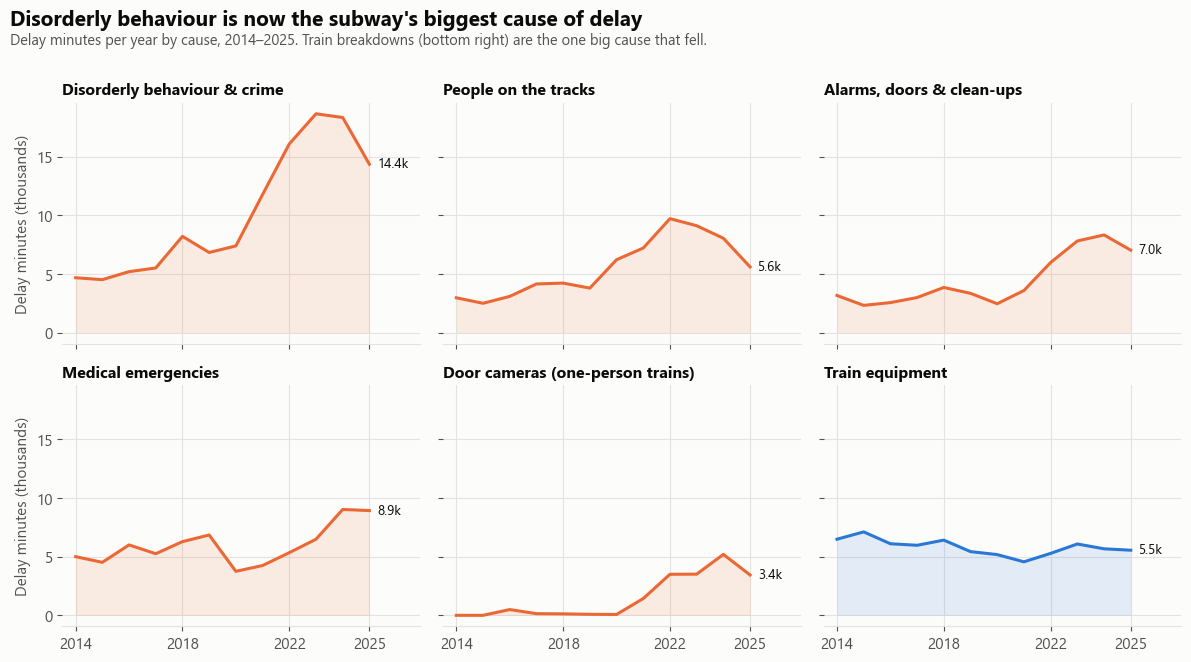

In [13]:
# Chart 3: six causes over time, one small chart each
cause_year = run_sql("SELECT * FROM mart_cause_year")
panels = ["Disorderly behaviour & crime", "People on the tracks", "Alarms, doors & clean-ups",
          "Medical emergencies", "Door cameras (one-person trains)", "Train equipment"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.4), sharex=True, sharey=True)
for ax, cause in zip(axes.flat, panels):
    rows = cause_year[cause_year["cause_group"] == cause]
    minutes = rows.set_index("year")["delay_minutes"]
    minutes = minutes.reindex(range(2014, 2026), fill_value=0)   # years with no delays count as 0
    minutes = minutes / 1000

    # blue if the cause improved (last 3 years vs first 3 years), orange if it got worse
    if minutes.iloc[-3:].mean() < minutes.iloc[:3].mean():
        colour = BLUE
    else:
        colour = ORANGE

    ax.fill_between(minutes.index, minutes.values, color=colour, alpha=0.12, lw=0)
    ax.plot(minutes.index, minutes.values, color=colour, lw=2.2)
    ax.set_title(cause, fontsize=11.5, pad=6)
    last_value = minutes.iloc[-1]
    ax.text(2025.3, last_value, f"{last_value:.1f}k", ha="left", va="center", fontsize=9.5, color=INK)
    ax.set_xticks([2014, 2018, 2022, 2025])
    ax.set_xlim(2013.5, 2026.9)

axes[0, 0].set_ylabel("Delay minutes (thousands)")
axes[1, 0].set_ylabel("Delay minutes (thousands)")
fig.suptitle("Disorderly behaviour is now the subway's biggest cause of delay", x=0.01, ha="left",
             fontsize=15, fontweight="bold", y=1.03)
fig.text(0.01, 0.975, "Delay minutes per year by cause, 2014–2025. Train breakdowns (bottom right) are the one big cause that fell.",
         color=INK_2, fontsize=10.5)
fig.tight_layout()
save(fig, "03_causes_over_time.png")
plt.show()

Disorderly-behaviour delays peaked in 2023 (18,700 minutes) and fell 23% by 2025 (14,400). The city and the TTC
added safety ambassadors, security guards and special constables in January 2023 after a string of violent
incidents. The timing fits, but this data can't show that the extra staff caused the fall.

The single biggest code is **SUDP, "disorderly patron"**, at 12% of all delay minutes in 2023–25:

In [14]:
run_sql("""
    SELECT rank, code, description, cause_group, delay_minutes, delays, share_of_minutes_pct
    FROM mart_codes
    WHERE rank <= 12
""")

,rank,code,description,cause_group,delay_minutes,delays,share_of_minutes_pct
0,1,SUDP,Disorderly patron,Disorderly behaviour & crime,25412.0,3644,11.9
1,2,SUUT,Unauthorized at track level,People on the tracks,15349.0,1131,7.2
2,3,SUO,Security other,Disorderly behaviour & crime,14414.0,1449,6.8
3,4,MUIR,Injured/ill customer on train – medical aid re...,Medical emergencies,11939.0,1652,5.6
4,5,PUOPO,Opto (communications) train door monitoring,Door cameras (one-person trains),11916.0,2141,5.6
5,6,MUI,Injured/ill customer on train – transported,Medical emergencies,11360.0,994,5.3
6,7,MUPAA,Paa – no trouble found,"Alarms, doors & clean-ups",9658.0,2346,4.5
7,8,MUPR1,Priority one – train in contact with person,People on the tracks,7401.0,97,3.5
8,9,MUPLB,Fire/smoke plan b – source ttc (track level),Fire & smoke,5779.0,153,2.7
9,10,SUAP,Assualt / patron involved,Disorderly behaviour & crime,5149.0,468,2.4


## 4. Short incidents are common; long ones do the damage

In [15]:
severity = run_sql("SELECT * FROM mart_severity ORDER BY bucket_order")
severity

,bucket,bucket_order,incidents,delay_minutes,share_of_incidents_pct,share_of_minutes_pct
0,0 (no delay),0,48354,0.0,64.4,0.0
1,1-4 min,1,11466,39251.0,15.3,18.4
2,5-9 min,2,10117,62517.0,13.5,29.3
3,10-29 min,3,4468,67681.0,6.0,31.8
4,30-59 min,4,470,18096.0,0.6,8.5
5,60+ min,5,198,25622.0,0.3,12.0


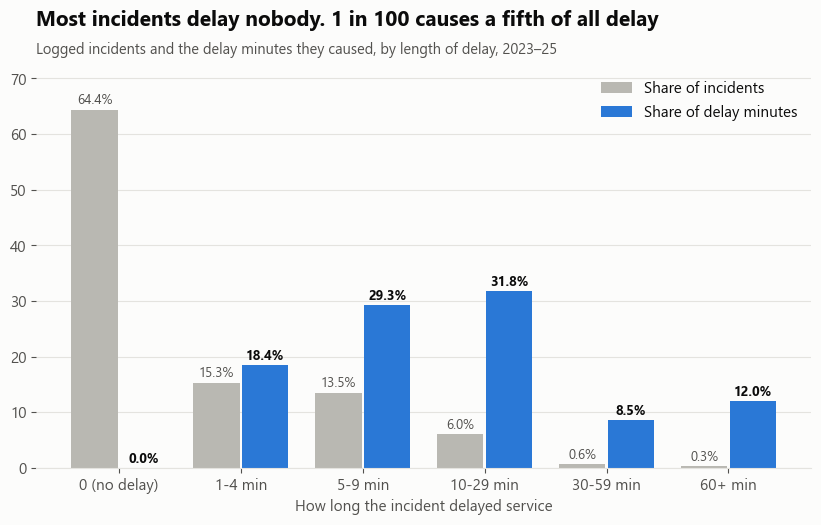

In [16]:
# Chart 4: share of incidents vs share of delay minutes, side by side for each length of delay
fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(severity))
ax.bar(x - 0.2, severity["share_of_incidents_pct"], width=0.38, color=NEUTRAL, label="Share of incidents")
ax.bar(x + 0.2, severity["share_of_minutes_pct"], width=0.38, color=BLUE, label="Share of delay minutes")

for i in range(len(severity)):
    incidents_pct = severity["share_of_incidents_pct"].iloc[i]
    minutes_pct = severity["share_of_minutes_pct"].iloc[i]
    ax.text(i - 0.2, incidents_pct + 1, f"{incidents_pct:.1f}%", ha="center", fontsize=9.5, color=INK_2)
    ax.text(i + 0.2, minutes_pct + 1, f"{minutes_pct:.1f}%", ha="center", fontsize=9.5, color=INK, fontweight="bold")

ax.set_xticks(x, severity["bucket"])
ax.set_ylim(0, 72)
ax.set_xlabel("How long the incident delayed service")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right")
titles(ax, "Most incidents delay nobody. 1 in 100 causes a fifth of all delay",
       "Logged incidents and the delay minutes they caused, by length of delay, 2023–25")
save(fig, "04_severity.png")
plt.show()

## 5. Did Line 1's new signal system help?

Line 1 switched from its old fixed-block signals to **automatic train control (ATC)** section by section from
2017, finishing on **24 September 2022**. Line 2 still runs on the old system, so it shows what probably would have
happened to Line 1 without ATC (a *difference-in-differences* design).

Outcome: signal-system failures (track circuits, train stops, signal and ATC equipment; not radios, cameras or
weather) that delayed a train. Before = 2014–16, after = October 2022 – August 2026. The 2017–22 roll-out is left out.

In [17]:
signals = run_sql("SELECT * FROM mart_signal_monthly")

# average month for each line, before and after the upgrade
columns = ["signal_delays", "signal_minutes", "signal_events", "other_minutes"]
signals.groupby(["line_name", "atc_period"])[columns].mean().round(1)

signal_delays  signal_minutes  signal_events  other_minutes
line_name atc_period                                                             
Line 1    after                 7.9            78.0           11.7         3175.6
          before               12.3            80.8           32.4         1224.9
          transition            9.1            81.5           20.2         1993.0
Line 2    after                11.3           116.4           21.6         2258.2
          before                9.4            56.0           24.4         1306.1
          transition            9.2            61.0           18.2         1503.6
Line 4    after                 2.0            30.7            3.9          205.2
          before                1.8            15.6            4.0          144.9
          transition            1.9            20.1            3.3          123.0

In [18]:
def diff_in_diff(outcome, control_line="Line 2"):
    """Difference-in-differences with a Poisson model on monthly counts.

    Compares Line 1 with a control line, before and after the upgrade. The 'line1:after' term is the extra
    change on Line 1 after the upgrade. As a rate ratio, 0.5 would mean half the failures the control line's
    trend predicts.
    """
    lines = ["Line 1", control_line]
    periods = ["before", "after"]
    data = signals[signals["line_name"].isin(lines) & signals["atc_period"].isin(periods)].copy()
    data["line1"] = (data["line_name"] == "Line 1").astype(int)
    data["after"] = (data["atc_period"] == "after").astype(int)

    model = smf.glm(f"{outcome} ~ line1 * after", data=data, family=sm.families.Poisson())
    fit = model.fit(cov_type="HC1", scale="X2")   # robust standard errors

    low, high = fit.conf_int().loc["line1:after"]
    result = {
        "rate ratio": np.exp(fit.params["line1:after"]),
        "95% CI low": np.exp(low),
        "95% CI high": np.exp(high),
        "p-value": fit.pvalues["line1:after"],
    }
    return pd.Series(result)


results = pd.DataFrame({
    "signal delays vs Line 2": diff_in_diff("signal_delays"),
    "signal delay minutes vs Line 2": diff_in_diff("signal_minutes"),
    "all signal events vs Line 2": diff_in_diff("signal_events"),
    "signal delays vs Line 4": diff_in_diff("signal_delays", "Line 4"),
    "placebo: non-signal minutes vs Line 2": diff_in_diff("other_minutes"),
}).T

for name, row in results.iterrows():
    print(f"{name}: rate ratio {row['rate ratio']:.2f} "
          f"(95% CI {row['95% CI low']:.2f}-{row['95% CI high']:.2f}), p = {row['p-value']:.4f}")

signal delays vs Line 2: rate ratio 0.53 (95% CI 0.39-0.73), p = 0.0001
signal delay minutes vs Line 2: rate ratio 0.46 (95% CI 0.29-0.74), p = 0.0011
all signal events vs Line 2: rate ratio 0.41 (95% CI 0.31-0.55), p = 0.0000
signal delays vs Line 4: rate ratio 0.58 (95% CI 0.37-0.91), p = 0.0187
placebo: non-signal minutes vs Line 2: rate ratio 1.50 (95% CI 1.31-1.72), p = 0.0000


- **Signal delays on Line 1 fell to about half (0.53×) of what Line 2's trend implies**, and the 95% interval
  (0.39–0.73) excludes "no effect". Using Line 4 as the comparison instead gives 0.58.
- **Placebo check:** if Line 1 had simply become better run in general, its *other* delays would have fallen too.
  They rose faster than Line 2's (1.50×), so the improvement is specific to signals.
- **Parallel trends:** before the upgrade, the two lines' signal delays moved together (test below).
- Line 1 also gained six stations in 2017, built with ATC from the start. More track should mean more failures,
  so if anything this understates the effect.

In [19]:
# parallel trends check: before the upgrade, did the two lines' signal delays change at the same rate?
pre = signals[(signals["atc_period"] == "before") & signals["line_name"].isin(["Line 1", "Line 2"])].copy()
pre["t"] = (pre["month"].dt.year - 2014) * 12 + pre["month"].dt.month   # month number: 1, 2, 3, ...
pre["line1"] = (pre["line_name"] == "Line 1").astype(int)

trend_model = smf.glm("signal_delays ~ line1 * t", data=pre, family=sm.families.Poisson())
trend_fit = trend_model.fit(cov_type="HC1", scale="X2")
difference = trend_fit.params["line1:t"]
p_value = trend_fit.pvalues["line1:t"]
print(f"difference in monthly trend before the upgrade: {difference:+.4f} (p = {p_value:.2f})")

difference in monthly trend before the upgrade: -0.0002 (p = 0.98)


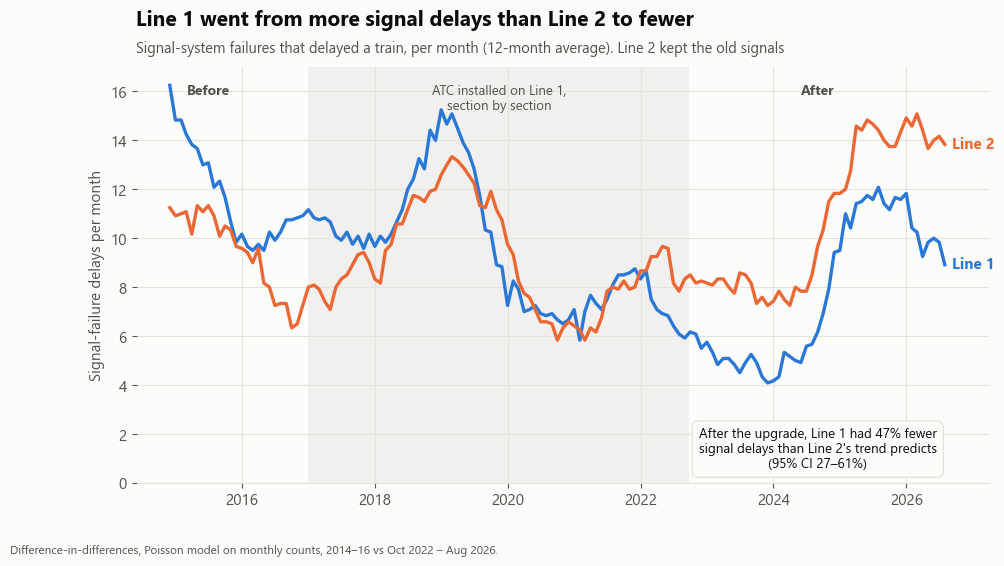

In [20]:
# Chart 5: signal delays on Line 1 and Line 2 (12-month average), with the upgrade years shaded
main_result = results.loc["signal delays vs Line 2"]
fewer_pct = (1 - main_result["rate ratio"]) * 100
fewer_low = (1 - main_result["95% CI high"]) * 100
fewer_high = (1 - main_result["95% CI low"]) * 100

fig, ax = plt.subplots(figsize=(11, 5.4))
for line in ["Line 1", "Line 2"]:
    rows = signals[signals["line_name"] == line].set_index("month")
    smooth = rows["signal_delays"].rolling(12).mean()
    ax.plot(smooth.index, smooth.values, color=LINE_COLOURS[line], lw=2.4)
    ax.text(smooth.index[-1] + pd.Timedelta(days=40), smooth.values[-1], line, color=LINE_COLOURS[line],
            fontweight="bold", va="center", fontsize=11)

ax.axvspan(pd.Timestamp("2017-01-01"), pd.Timestamp("2022-09-24"), color=GRID, alpha=0.45, lw=0)
ax.text(pd.Timestamp("2019-11-15"), 16.3, "ATC installed on Line 1,\nsection by section", ha="center",
        color=INK_2, fontsize=9.5, va="top")
ax.text(pd.Timestamp("2015-07-01"), 16.3, "Before", ha="center", color=INK_2, fontsize=10, va="top", fontweight="bold")
ax.text(pd.Timestamp("2024-09-01"), 16.3, "After", ha="center", color=INK_2, fontsize=10, va="top", fontweight="bold")
result_text = (f"After the upgrade, Line 1 had {fewer_pct:.0f}% fewer\n"
               f"signal delays than Line 2's trend predicts\n"
               f"(95% CI {fewer_low:.0f}–{fewer_high:.0f}%)")
ax.text(pd.Timestamp("2024-09-01"), 0.5, result_text, ha="center", fontsize=9.6, color=INK, va="bottom",
        bbox=dict(fc=SURFACE, ec=GRID, boxstyle="round,pad=0.5"))

ax.set_ylim(0, 17)
ax.set_xlim(pd.Timestamp("2014-06-01"), pd.Timestamp("2027-04-01"))
ax.set_ylabel("Signal-failure delays per month")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
titles(ax, "Line 1 went from more signal delays than Line 2 to fewer",
       "Signal-system failures that delayed a train, per month (12-month average). Line 2 kept the old signals")
footnote(fig, "Difference-in-differences, Poisson model on monthly counts, 2014–16 vs Oct 2022 – Aug 2026.", y=-0.02)
save(fig, "05_atc_signals.png")
plt.show()

Before the upgrade, Line 1 had *more* signal delays than Line 2 (12.3 vs 9.4 a month); since then it has had fewer
(7.9 vs 11.3). The gap was widest in 2023. Both lines have been getting worse since, and Line 1's increase comes
from the new system's own parts, mainly axle counters and track switches:

In [21]:
run_sql("""
    SELECT year(month) AS year,
           line_name,
           SUM(signal_delays) AS signal_delays,
           SUM(signal_minutes) AS signal_minutes
    FROM mart_signal_monthly
    WHERE month >= DATE '2023-01-01' AND month < DATE '2026-01-01'
      AND line_name IN ('Line 1', 'Line 2')
    GROUP BY year(month), line_name
    ORDER BY year, line_name
""")

,year,line_name,signal_delays,signal_minutes
0,2023,Line 1,49.0,463.0
1,2023,Line 2,87.0,1013.0
2,2024,Line 1,113.0,1035.0
3,2024,Line 2,142.0,1390.0
4,2025,Line 1,139.0,1235.0
5,2025,Line 2,172.0,2088.0


In [22]:
# the three biggest kinds of signal failure on Line 1 in each year since the upgrade
run_sql("""
    WITH yearly_types AS (
        SELECT year,
               description,
               COUNT(*) FILTER (WHERE is_delay) AS delays,
               SUM(min_delay) AS delay_minutes
        FROM incidents
        WHERE is_signal_failure AND line = '1' AND year BETWEEN 2023 AND 2025
        GROUP BY year, description
    ),
    ranked AS (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY year ORDER BY delay_minutes DESC) AS rn
        FROM yearly_types
    )
    SELECT year, description, delays, delay_minutes
    FROM ranked
    WHERE rn <= 3
    ORDER BY year, delay_minutes DESC
""")

,year,description,delays,delay_minutes
0,2023,Track switch failure – s/e/c related problem,18,265.0
1,2023,Signals axle counter block failure,21,105.0
2,2023,Signals zone controller failure,5,67.0
3,2024,Signals axle counter block failure,92,552.0
4,2024,Track switch failure – s/e/c related problem,8,275.0
5,2024,Signals zone controller failure,2,82.0
6,2025,Signals axle counter block failure,64,435.0
7,2025,Track switch failure – s/e/c related problem,15,388.0
8,2025,Atc signals other,45,222.0


The failure *types* changed completely. The old system's track circuits and train stops (trackside trip arms)
almost never fail on Line 1 any more; ATC brought its own failures (axle counters, zone controllers).

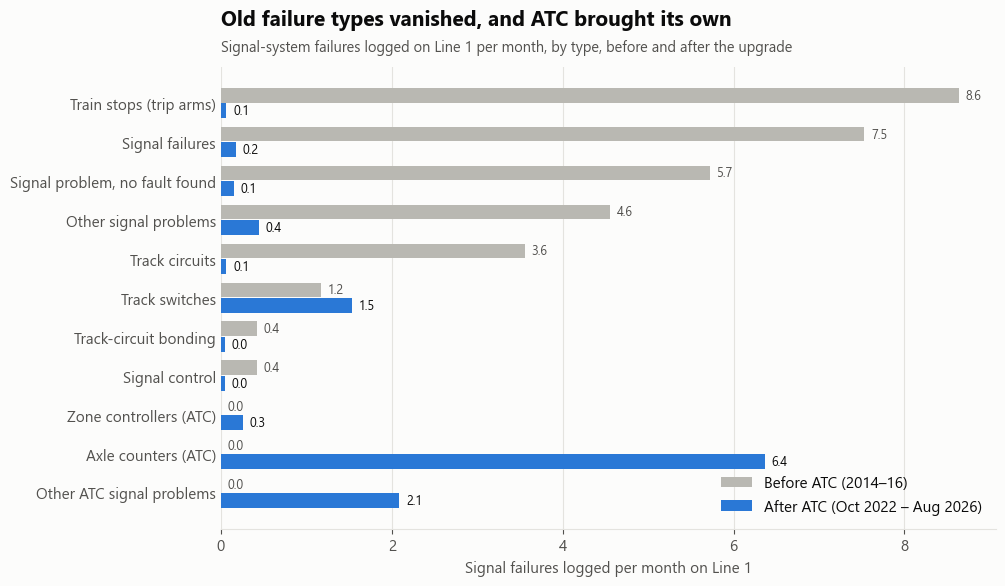

In [23]:
# Chart 6: signal failures per month on Line 1 by type, before and after the upgrade
codes = run_sql("""
    SELECT atc_period, code, description, events,
           events / CASE atc_period WHEN 'before' THEN 36 ELSE 47 END AS events_per_month
    FROM mart_signal_codes
    WHERE line_name = 'Line 1'
""")

# readable names for the TTC codes
names = {"PUSTS": "Train stops (trip arms)", "PUSI": "Signal failures", "PUSNT": "Signal problem, no fault found",
         "PUSO": "Other signal problems", "PUSTC": "Track circuits", "PUSSW": "Track switches",
         "PUSAC": "Axle counters (ATC)", "PUATC": "Other ATC signal problems", "PUCSC": "Signal control",
         "PUTTC": "Track-circuit bonding", "PUTSC": "Signal control (track)", "PUSZC": "Zone controllers (ATC)",
         "PUCSS": "Central signalling", "PUSIO": "Smart IO (ATC)"}

# one row per code, one column per period
wide = codes.pivot_table(index="code", columns="atc_period", values="events_per_month", fill_value=0)
wide = wide[wide.max(axis=1) >= 0.25].copy()    # keep codes with at least one failure every 4 months

labels = []
for code in wide.index:
    if code in names:
        labels.append(names[code])
    else:
        labels.append(code)
wide["name"] = labels
wide = wide.sort_values("before")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(wide))
ax.barh(y + 0.2, wide["before"], height=0.38, color=NEUTRAL, label="Before ATC (2014–16)")
ax.barh(y - 0.2, wide["after"], height=0.38, color=BLUE, label="After ATC (Oct 2022 – Aug 2026)")
for i in range(len(wide)):
    before = wide["before"].iloc[i]
    after = wide["after"].iloc[i]
    ax.text(before + 0.08, i + 0.2, f"{before:.1f}", va="center", fontsize=9, color=INK_2)
    ax.text(after + 0.08, i - 0.2, f"{after:.1f}", va="center", fontsize=9, color=INK)

ax.set_yticks(y, wide["name"])
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Signal failures logged per month on Line 1")
ax.legend(loc="lower right")
titles(ax, "Old failure types vanished, and ATC brought its own",
       "Signal-system failures logged on Line 1 per month, by type, before and after the upgrade")
save(fig, "06_signal_failure_types.png")
plt.show()

## 6. One-person trains: a new kind of delay

With one-person train operation (OPTO), the guard at the back is gone and the operator watches the doors on
camera screens. Line 4 switched in 2016; Line 1 started in November 2021 and was fully converted by late 2022.
When the cameras or screens fail, trains are held. Those delays have their own code (PUOPO and related).

In [24]:
door = run_sql("SELECT * FROM mart_door_monitoring ORDER BY year, line_name")
door.pivot_table(index="year", columns="line_name", values="delay_minutes", fill_value=0)

line_name,Line 1,Line 4
year,,
2016,0.0,491.0
2017,0.0,143.0
2018,0.0,125.0
2019,0.0,87.0
2020,0.0,75.0
2021,1289.0,142.0
2022,3106.0,390.0
2023,3235.0,272.0
2024,4875.0,316.0


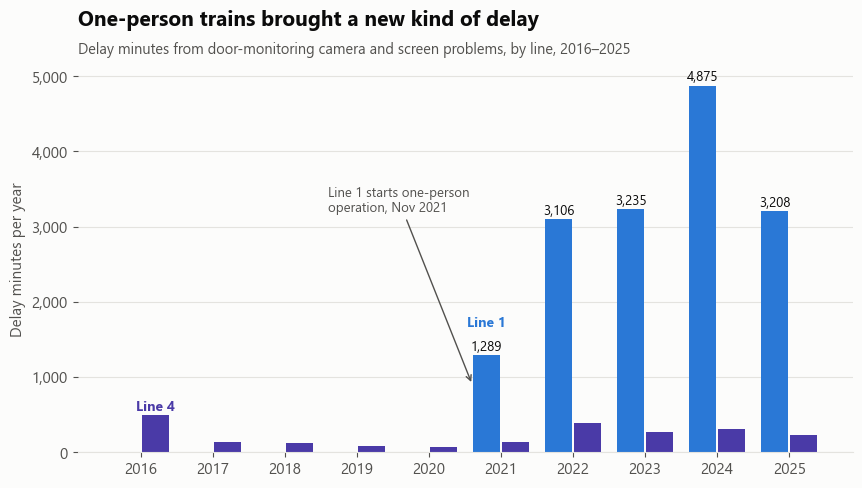

In [25]:
# Chart 7: door-camera delay minutes per year on Line 1 and Line 4
door_minutes = door[door["year"] <= 2025].pivot_table(index="year", columns="line_name", values="delay_minutes",
                                                      fill_value=0)
door_minutes = door_minutes.reindex(range(2016, 2026), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(door_minutes))
ax.bar(x - 0.2, door_minutes["Line 1"], width=0.38, color=BLUE)
ax.bar(x + 0.2, door_minutes["Line 4"], width=0.38, color=VIOLET)

# label the Line 1 bars (skip the years with no delays)
for i in range(len(door_minutes)):
    value = door_minutes["Line 1"].iloc[i]
    if value > 0:
        ax.text(i - 0.2, value + 60, f"{value:,.0f}", ha="center", fontsize=9.5, color=INK)

ax.text(0.2, door_minutes["Line 4"].iloc[0] + 60, "Line 4", ha="center", color=VIOLET, fontsize=10, fontweight="bold")
ax.text(5 - 0.2, door_minutes["Line 1"].iloc[5] + 380, "Line 1", ha="center", color=BLUE, fontsize=10, fontweight="bold")
ax.annotate("Line 1 starts one-person\noperation, Nov 2021", (4.6, 900), xytext=(2.6, 3200),
            fontsize=9.5, color=INK_2, arrowprops=dict(arrowstyle="->", color=INK_2, lw=1))
ax.set_xticks(x, door_minutes.index)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Delay minutes per year")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
titles(ax, "One-person trains brought a new kind of delay",
       "Delay minutes from door-monitoring camera and screen problems, by line, 2016–2025")
save(fig, "07_door_cameras.png")
plt.show()

Since 2022, Line 1 has lost **about 3,600 minutes a year** to door-camera problems: 5% of all subway delay minutes,
and more than its signal failures after ATC. This doesn't say one-person operation was a bad trade (it frees up
staff, and this analysis can't count the delays guards used to cause or prevent), but it's a cost worth tracking.

In [26]:
line1_per_year = door_minutes.loc[2022:2025, "Line 1"].mean()
print(f"Line 1 door-camera delay minutes, average year 2022-25: {line1_per_year:,.0f}")

Line 1 door-camera delay minutes, average year 2022-25: 3,606


## 7. When and where

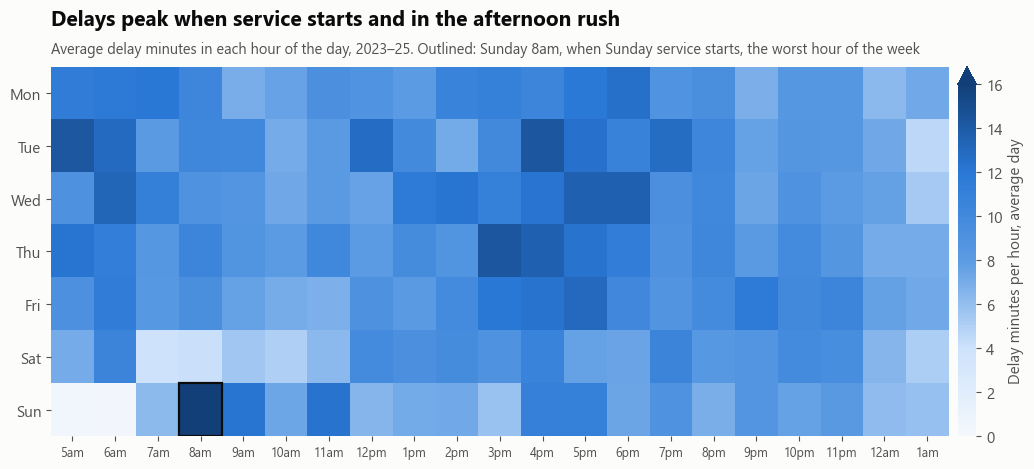

In [27]:
# Chart 8: heatmap of delay minutes by weekday and hour
hour_weekday = run_sql("SELECT * FROM mart_hour_weekday")
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hours = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 0, 1]   # the subway's day


def hour_label(hour):
    """Turn 24-hour clock hours into labels like 5am and 3pm."""
    if hour == 0:
        return "12am"
    if hour < 12:
        return f"{hour}am"
    if hour == 12:
        return "12pm"
    return f"{hour - 12}pm"


grid = hour_weekday.pivot_table(index="weekday", columns="hour", values="minutes_per_day")
grid = grid.reindex(index=days, columns=hours)

fig, ax = plt.subplots(figsize=(12, 4.8))
blues = LinearSegmentedColormap.from_list("blues", ["#f4f8fd", BLUE_LIGHT, "#5b9be3", BLUE, "#123f78"])
image = ax.imshow(grid.values, aspect="auto", cmap=blues, vmin=0, vmax=16)   # one cell reaches 22; capped at 16
hour_labels = [hour_label(h) for h in hours]
ax.set_xticks(range(len(hours)), hour_labels, fontsize=9)
ax.set_yticks(range(7), [day[:3] for day in days])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# outline the worst hour of the week: Sunday 8am
row = days.index("Sunday")
column = hours.index(8)
ax.add_patch(plt.Rectangle((column - 0.5, row - 0.5), 1, 1, fill=False, ec=INK, lw=1.6))

colourbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.01, extend="max")
colourbar.set_label("Delay minutes per hour, average day", color=INK_2)
colourbar.outline.set_visible(False)
titles(ax, "Delays peak when service starts and in the afternoon rush",
       "Average delay minutes in each hour of the day, 2023–25. Outlined: Sunday 8am, when Sunday service starts, "
       "the worst hour of the week")
save(fig, "08_when.png")
plt.show()

The first hour of service (5–6am on weekdays and Saturdays, 7–8am on Sundays) fails for different reasons from the
rest of the day: trains, track, crews and overnight work that isn't finished on time, rather than passengers.

In [28]:
run_sql("""
    WITH x AS (
        SELECT min_delay,
               CASE WHEN (weekday = 'Sunday' AND hour IN (7, 8)) OR (weekday <> 'Sunday' AND hour IN (5, 6))
                         THEN 'first hour of service'
                    WHEN weekday NOT IN ('Saturday', 'Sunday') AND hour BETWEEN 15 AND 18 THEN 'weekday 3-7pm'
                    ELSE 'rest of the day' END AS slot,
               CASE WHEN cause_group IN ('Disorderly behaviour & crime', 'Medical emergencies', 'People on the tracks',
                                         'Alarms, doors & clean-ups') THEN 'passengers & public'
                    WHEN cause_group IN ('Fire & smoke', 'Weather', 'Other & unclassified') THEN 'other'
                    ELSE 'trains, track, crews & works' END AS who
        FROM incidents
        WHERE year BETWEEN 2023 AND 2025
    )
    SELECT slot,
           who,
           SUM(min_delay) AS delay_minutes,
           ROUND(100 * SUM(min_delay) / SUM(SUM(min_delay)) OVER (PARTITION BY slot), 1) AS pct_of_slot
    FROM x
    GROUP BY slot, who
    ORDER BY slot, delay_minutes DESC
""")

,slot,who,delay_minutes,pct_of_slot
0,first hour of service,"trains, track, crews & works",19506.0,76.5
1,first hour of service,passengers & public,3954.0,15.5
2,first hour of service,other,2050.0,8.0
3,rest of the day,passengers & public,93657.0,62.6
4,rest of the day,"trains, track, crews & works",45176.0,30.2
5,rest of the day,other,10811.0,7.2
6,weekday 3-7pm,passengers & public,24103.0,63.4
7,weekday 3-7pm,"trains, track, crews & works",11393.0,30.0
8,weekday 3-7pm,other,2517.0,6.6


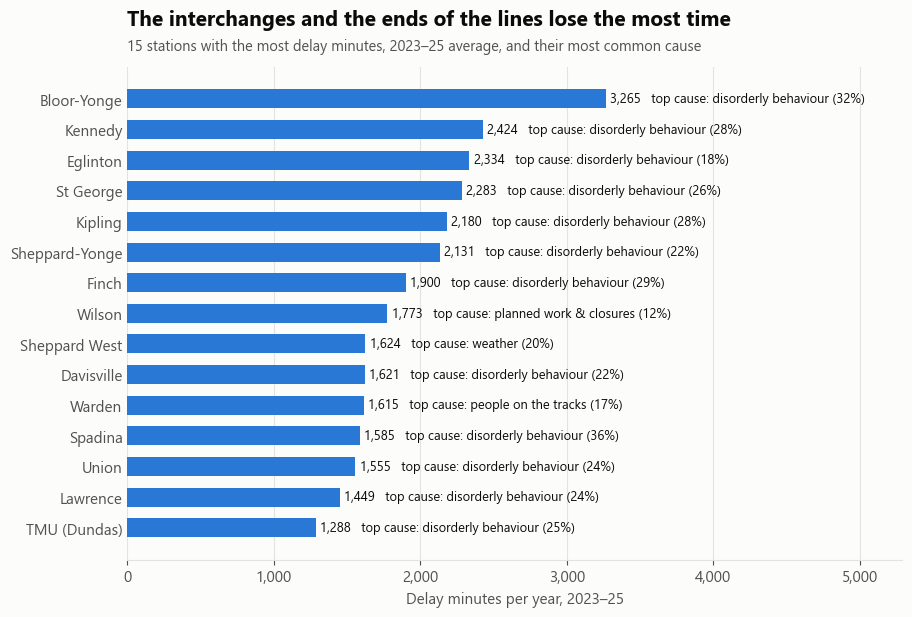

top cause is disorderly behaviour at 12 of the top 15


In [29]:
# Chart 9: the 15 stations with the most delay minutes, and each one's top cause
stations = run_sql("SELECT * FROM mart_station WHERE rank <= 15 ORDER BY rank DESC")

short_names = {"Disorderly behaviour & crime": "disorderly behaviour", "People on the tracks": "people on the tracks",
               "Signals & communications": "signals", "Weather": "weather", "Crew & operations": "crew & operations",
               "Train equipment": "train equipment", "Fire & smoke": "fire & smoke", "Medical emergencies": "medical"}

fig, ax = plt.subplots(figsize=(10, 6.4))
ax.barh(stations["station"], stations["minutes_per_year"], color=BLUE, height=0.62)
for i in range(len(stations)):
    minutes = stations["minutes_per_year"].iloc[i]
    cause = stations["top_cause"].iloc[i]
    share = stations["top_cause_share_pct"].iloc[i]
    if cause in short_names:
        cause_text = short_names[cause]
    else:
        cause_text = cause.lower()
    ax.text(minutes + 30, i, f"{minutes:,.0f}   top cause: {cause_text} ({share:.0f}%)", va="center", fontsize=9.3,
            color=INK)

ax.set_xlim(0, stations["minutes_per_year"].max() * 1.62)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Delay minutes per year, 2023–25")
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
titles(ax, "The interchanges and the ends of the lines lose the most time",
       "15 stations with the most delay minutes, 2023–25 average, and their most common cause")
save(fig, "09_stations.png")
plt.show()

disorderly_top = (stations["top_cause"] == "Disorderly behaviour & crime").sum()
print("top cause is disorderly behaviour at", disorderly_top, "of the top 15")

Bloor-Yonge and St George (where Lines 1 and 2 meet), Kennedy, Kipling and Finch (the ends of the lines) top the
list, and disorderly behaviour is the leading cause at 12 of the top 15. Line ends collect incidents partly because
trains are checked and cleared there, so this ranks where incidents are *logged*, not necessarily where they begin.

## 8. Limitations

- **Delay minutes measure service, not passengers.** A 10-minute delay at 8am affects far more riders than one at
  11pm. The data has no ridership.
- **Logging can change.** Some of the rise in disorderly-behaviour incidents may be better reporting (the city and TTC added
  safety staff in January 2023 after a string of violent incidents), and new codes appeared in 2026.
- **The ATC comparison assumes Line 2 shows what Line 1 would have done without the upgrade.** The two lines
  tracked each other before the upgrade, which supports this, but it can't be proven.
- **Line ends and interchanges** log incidents that may have started elsewhere on the line.
- 2026 covers January to August only and is left out of yearly comparisons.